In [4]:
import matplotlib.pyplot as plt
import numpy as np
from gulps.viz.polytope_viz import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.synthesis.gulps_decomposer import GulpsDecomposer
from gulps import GulpsDecompositionPass
from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import render_path

In [5]:
# import networkx as nx

# # Directed graph so the (from → to) structure is preserved
# G = nx.DiGraph()

# # Add edges with the form (from, label, to)
# edges = [
#     ("id", "b", "b"),
#     ("b", "b", "c_i-1"),
#     ("c_i-1", "b", "d1"),
#     ("d1", "b", "c_i"),
#     ("id", "c_i-1", "c_i-1"),
#     ("c_i-1", "g_i", "c_i"),
#     ("b", "m", "d1"),
#     ("b", "b", "g_i"),
#     ("g_i", "b", "d2"),
#     ("d2", "b", "c_i"),
#     ("id", "g_i", "g_i"),
#     ("g_i", "c_i-1", "c_i"),
#     ("b", "m", "d2"),
# ]

# # Insert edges
# for u, lbl, v in edges:
#     G.add_edge(u, v, label=lbl)

# import matplotlib.pyplot as plt

# pos = nx.arf_layout(G)
# nx.draw(G, pos, with_labels=True, node_size=2000, font_size=12)
# edge_labels = nx.get_edge_attributes(G, "label")
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# plt.show()

In [6]:
from gulps.synthesis.recover_equiv import recover_local_equivalence


def recover_equivalent_circuit(target_gate, current_gate):
    k1, k2, k3, k4, global_phase = recover_local_equivalence(target_gate, current_gate)
    temp = QuantumCircuit(2, global_phase=global_phase)
    temp.append(UnitaryGate(k1), [0])
    temp.append(UnitaryGate(k2), [1])
    temp.append(current_gate, [0, 1])
    temp.append(UnitaryGate(k3), [0])
    temp.append(UnitaryGate(k4), [1])
    return temp

In [7]:
class BGate(UnitaryGate):
    def __init__(self, theta=np.pi / 2):
        """BGate(theta) constructor."""
        c1 = np.cos(theta / 4)
        c3 = np.cos(3 * theta / 4)
        s1 = np.sin(theta / 4)
        s3 = np.sin(3 * theta / 4)
        return super().__init__(
            [
                [c1, 0, 0, 1j * s1],
                [0, c3, 1j * s3, 0],
                [0, 1j * s3, c3, 0],
                [1j * s1, 0, 0, c1],
            ],
            label="b",
        )


def b_sandwich(target, interior_only=False, second_dagger=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    temp = QuantumCircuit(2)
    if interior_only:
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        return temp
    else:
        temp.append(BGate(), [0, 1])
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        if second_dagger:
            temp.u(np.pi, 0, 0, 0)
            temp.u(np.pi, -np.pi / 2, np.pi / 2, 1)
            temp.append(BGate().inverse(), [0, 1])
        else:
            temp.append(BGate(), [0, 1])
        return temp

In [12]:
# b_sandwich(GateInvariants.from_weyl((0, 0, 0))).draw()
qc = QuantumCircuit(2)
qc.append(Operator(b_sandwich(GateInvariants.from_weyl((0, 0, 0)))), [0, 1])
qc.decompose().draw()

global phase: π/2
      ┌────────────┐ 
q_0: ─┤ U(0,-π,-π) ├─
     ┌┴────────────┴┐
q_1: ┤ U(0,π/2,π/2) ├
     └──────────────┘

In [318]:
isa = [
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

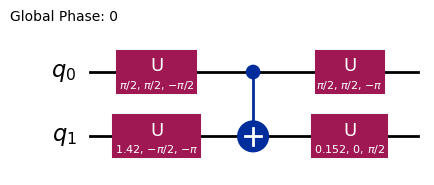

In [319]:
qc = QuantumCircuit(2)
qc.append(Operator(BGate().to_matrix() @ BGate().to_matrix()), [0, 1])
qc.decompose().draw("mpl")

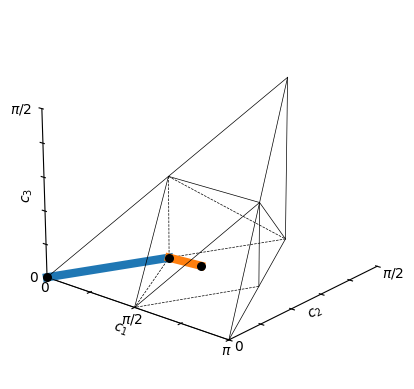

In [320]:
target = GateInvariants.from_weyl((0.5, 0.25, 0.25))
target = GateInvariants.from_unitary(random_unitary(4))
sentence_out, intermediates = decomposer._best_decomposition(target)
render_path(intermediates);

In [347]:
intermediates[-1].weyl

array([0.47957072, 0.22101323, 0.02707246])

In [321]:
# identity @ sentence_out[0] ~= intermediates[0]
# intermediates[0] @ sentence_out[1] ~= intermediates[1]
Cim1 = intermediates[0]
Gi = sentence_out[1]
Ci = intermediates[1]

from qiskit.circuit.library import U3Gate
from numpy import kron

# some random L1, L2
l1 = Operator(
    kron(
        UGate(*np.random.uniform(0, 2 * np.pi, 3)),
        UGate(*np.random.uniform(0, 2 * np.pi, 3)),
    )
)
l2 = Operator(
    kron(
        UGate(*np.random.uniform(0, 2 * np.pi, 3)),
        UGate(*np.random.uniform(0, 2 * np.pi, 3)),
    )
)

M = (
    l1.adjoint()
    @ Operator(BGate().inverse())
    @ Operator(Ci.unitary)
    @ Operator(BGate().inverse())
    @ l2.adjoint()
)

Minv = GateInvariants.from_unitary(M.data)
print(Minv.weyl)
b_sandwich(Minv).draw()

[0.346665   0.24688567 0.01301339]


┌────┐┌─────────────┐                              ┌────┐
q_0: ┤0   ├┤ Ry(-1.0891) ├──────────────────────────────┤0   ├
     │  b │├─────────────┤┌─────────────┐┌─────────────┐│  b │
q_1: ┤1   ├┤ Rz(-1.5391) ├┤ Ry(-1.1283) ├┤ Rz(-1.5391) ├┤1   ├
     └────┘└─────────────┘└─────────────┘└─────────────┘└────┘

In [322]:
Operator(BGate().inverse()) @ Operator(Ci.unitary) @ Operator(BGate().inverse())

Operator([[ 0.19706209+0.18232781j,  0.36611927-0.3192132j ,
            0.5187347 +0.39415455j, -0.28311756+0.43287835j],
          [ 0.0788653 +0.34581234j,  0.05257665+0.03617572j,
           -0.52268535+0.15741888j,  0.47109861+0.59178249j],
          [ 0.34018374+0.28169348j, -0.73240696-0.27718038j,
           -0.17052137+0.21196254j, -0.33639656-0.06713117j],
          [-0.66760628+0.40167507j, -0.34803754+0.16002369j,
            0.40398695+0.2009097j ,  0.20599214+0.01477724j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [323]:
Operator(l1) @ M @ Operator(l2)

Operator([[ 0.19706209+0.18232781j,  0.36611927-0.3192132j ,
            0.5187347 +0.39415455j, -0.28311756+0.43287835j],
          [ 0.0788653 +0.34581234j,  0.05257665+0.03617572j,
           -0.52268535+0.15741888j,  0.47109861+0.59178249j],
          [ 0.34018374+0.28169348j, -0.73240696-0.27718038j,
           -0.17052137+0.21196254j, -0.33639656-0.06713117j],
          [-0.66760628+0.40167507j, -0.34803754+0.16002369j,
            0.40398695+0.2009097j ,  0.20599214+0.01477724j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [329]:
k1, k2, k3, k4, global_phase = recover_local_equivalence(M, Operator(b_sandwich(Minv)))
temp = QuantumCircuit(2, global_phase=global_phase)
temp.append(UnitaryGate(k1), [0])
temp.append(UnitaryGate(k2), [1])
temp.compose(b_sandwich(Minv), [0, 1], inplace=True)
temp.append(UnitaryGate(k3), [0])
temp.append(UnitaryGate(k4), [1])
print(GateInvariants.from_unitary(Operator(temp)).weyl)
print(Ci.weyl)
temp.draw(fold=-1)

[0.346665   0.24688567 0.01301339]
[0.47957072 0.22101323 0.02707246]


global phase: 1.7326
     ┌─────────┐┌────┐┌─────────────┐                              ┌────┐┌─────────┐
q_0: ┤ Unitary ├┤0   ├┤ Ry(-1.0891) ├──────────────────────────────┤0   ├┤ Unitary ├
     ├─────────┤│  b │├─────────────┤┌─────────────┐┌─────────────┐│  b │├─────────┤
q_1: ┤ Unitary ├┤1   ├┤ Rz(-1.5391) ├┤ Ry(-1.1283) ├┤ Rz(-1.5391) ├┤1   ├┤ Unitary ├
     └─────────┘└────┘└─────────────┘└─────────────┘└─────────────┘└────┘└─────────┘

In [325]:
Operator(temp) == M

True

In [326]:
k1, k2, k3, k4, global_phase = recover_local_equivalence(M, Operator(b_sandwich(Minv)))
temp2 = QuantumCircuit(2, global_phase=global_phase)
temp2.append(BGate(), [0, 1])
temp2.append(UnitaryGate(l2), [0, 1])
temp2.append(UnitaryGate(k1), [0])
temp2.append(UnitaryGate(k2), [1])
temp2.compose(b_sandwich(Minv), [0, 1], inplace=True)
temp2.append(UnitaryGate(k3), [0])
temp2.append(UnitaryGate(k4), [1])
temp2.append(UnitaryGate(l1), [0, 1])
temp2.append(BGate(), [0, 1])
print(GateInvariants.from_unitary(Operator(temp2)).weyl)
print(Ci.weyl)
Operator(temp2) == Operator(Ci.unitary)

[0.47957072 0.22101323 0.02707246]
[0.47957072 0.22101323 0.02707246]


True

In [327]:
# inspect the two pieces
k1, k2, k3, k4, global_phase = recover_local_equivalence(M, Operator(b_sandwich(Minv)))
temp3 = QuantumCircuit(2, global_phase=global_phase)
temp3.append(BGate(), [0, 1])
temp3.append(UnitaryGate(l2), [0, 1])
temp3.append(UnitaryGate(k1), [0])
temp3.append(UnitaryGate(k2), [1])
temp3.append(BGate(), [0, 1])
print(GateInvariants.from_unitary(Operator(temp3)).weyl)

[0.35243896 0.25962317 0.07874687]


In [328]:
# inspect the two pieces
k1, k2, k3, k4, global_phase = recover_local_equivalence(M, Operator(b_sandwich(Minv)))
temp4 = QuantumCircuit(2, global_phase=global_phase)
temp4.append(BGate(), [0, 1])
temp4.append(UnitaryGate(k3), [0])
temp4.append(UnitaryGate(k4), [1])
temp4.append(UnitaryGate(l1), [0, 1])
temp4.append(BGate(), [0, 1])
print(GateInvariants.from_unitary(Operator(temp4)).weyl)

[0.38236385 0.23092197 0.20371265]


In [366]:
# randomly generate l1, l2 and plot the pieces C_i1, G_i
N = 1000
cim1_list = []
gi_list = []

for i in tqdm(range(N)):
    # some random L1, L2
    l1 = Operator(
        kron(
            U3Gate(*np.random.uniform(0, 2 * np.pi, 3)),
            U3Gate(*np.random.uniform(0, 2 * np.pi, 3)),
        )
    )
    l2 = Operator(
        kron(
            U3Gate(*np.random.uniform(0, 2 * np.pi, 3)),
            U3Gate(*np.random.uniform(0, 2 * np.pi, 3)),
        )
    )

    M = (
        Operator(BGate().adjoint())
        @ Operator(Cim1.unitary).adjoint()
        @ Operator(Ci.unitary)
        @ Operator(Gi.unitary).adjoint()
        @ Operator(BGate().adjoint())
    )

    Minv = GateInvariants.from_unitary(M.data)
    # inspect the two pieces
    k1, k2, k3, k4, global_phase = recover_local_equivalence(
        M, Operator(b_sandwich(Minv))
    )
    temp3 = QuantumCircuit(2, global_phase=global_phase)
    temp3.append(BGate(), [0, 1])
    # temp3.append(UnitaryGate(l2), [0, 1])
    temp3.append(UnitaryGate(k1), [0])
    temp3.append(UnitaryGate(k2), [1])
    temp3.append(BGate(), [0, 1])
    # print(GateInvariants.from_unitary(Operator(temp3)).weyl)
    cim1_list.append(GateInvariants.from_unitary(Operator(temp3)))

    temp4 = QuantumCircuit(2, global_phase=global_phase)
    temp4.append(BGate(), [0, 1])
    temp4.append(UnitaryGate(k3), [0])
    temp4.append(UnitaryGate(k4), [1])
    # temp4.append(UnitaryGate(l1), [0, 1])
    temp4.append(BGate(), [0, 1])
    # print(GateInvariants.from_unitary(Operator(temp4)).weyl)
    gi_list.append(GateInvariants.from_unitary(Operator(temp4)))

100%|██████████| 1000/1000 [00:02<00:00, 370.77it/s]


In [370]:
b_sandwich(GateInvariants.from_weyl((0, 0, 0))).draw()

┌────┐ ┌───────┐                       ┌────┐
q_0: ┤0   ├─┤ Ry(0) ├───────────────────────┤0   ├
     │  b │┌┴───────┴─┐┌───────┐┌──────────┐│  b │
q_1: ┤1   ├┤ Rz(-π/2) ├┤ Ry(0) ├┤ Rz(-π/2) ├┤1   ├
     └────┘└──────────┘└───────┘└──────────┘└────┘

In [404]:
qc0 = QuantumCircuit(2, global_phase=np.pi / 2)
qc0.append(BGate(), [0, 1])
qc0.rz(np.pi, 1)
qc0.append(BGate(), [0, 1])
qc0.u(0, np.pi / 2, np.pi / 2, 1)
import qutip as qt

qt.Qobj(Operator(qc0).data)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -4.32978028e-17]
 [ 0.00000000e+00  1.00000000e+00 -4.32978028e-17  0.00000000e+00]
 [ 0.00000000e+00  4.32978028e-17  1.00000000e+00  0.00000000e+00]
 [ 4.32978028e-17  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

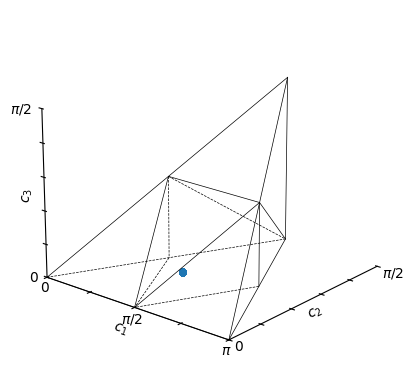

In [ ]:
from gulps.viz.invariant_viz import scatter_plot

scatter_plot(gi_list)

Proof of concept with no l

In [ ]:
# identity @ sentence_out[0] ~= intermediates[0]
# intermediates[0] @ sentence_out[1] ~= intermediates[1]
Cim1 = intermediates[0]
Gi = sentence_out[1]
Ci = intermediates[1]

M = Operator(BGate().inverse()) @ Operator(Ci.unitary) @ Operator(BGate().inverse())
Minv = GateInvariants.from_unitary(M.data)
print(Minv.weyl)
b_sandwich(Minv).draw()

[0.4763833  0.28245469 0.12022441]


┌────┐┌─────────────┐                              ┌────┐
q_0: ┤0   ├┤ Ry(-1.4966) ├──────────────────────────────┤0   ├
     │  b │├─────────────┤┌─────────────┐┌─────────────┐│  b │
q_1: ┤1   ├┤ Rz(-1.2675) ├┤ Ry(-1.2777) ├┤ Rz(-1.2675) ├┤1   ├
     └────┘└─────────────┘└─────────────┘└─────────────┘└────┘

In [147]:
k1, k2, k3, k4, global_phase = recover_local_equivalence(M, Operator(b_sandwich(Minv)))
temp = QuantumCircuit(2, global_phase=global_phase)
temp.append(BGate(), [0, 1])
temp.append(UnitaryGate(k1), [0])
temp.append(UnitaryGate(k2), [1])
temp.compose(b_sandwich(Minv), [0, 1], inplace=True)
temp.append(UnitaryGate(k3), [0])
temp.append(UnitaryGate(k4), [1])
temp.append(BGate(), [0, 1])
print(GateInvariants.from_unitary(Operator(temp)).weyl)
print(Ci.weyl)
temp.draw(fold=-1)

[0.41866096 0.27338507 0.07632615]
[0.41866096 0.27338507 0.07632615]


global phase: 5.6913
     ┌────┐┌─────────┐┌────┐┌─────────────┐                              ┌────┐┌─────────┐┌────┐
q_0: ┤0   ├┤ Unitary ├┤0   ├┤ Ry(-1.4966) ├──────────────────────────────┤0   ├┤ Unitary ├┤0   ├
     │  b │├─────────┤│  b │├─────────────┤┌─────────────┐┌─────────────┐│  b │├─────────┤│  b │
q_1: ┤1   ├┤ Unitary ├┤1   ├┤ Rz(-1.2675) ├┤ Ry(-1.2777) ├┤ Rz(-1.2675) ├┤1   ├┤ Unitary ├┤1   ├
     └────┘└─────────┘└────┘└─────────────┘└─────────────┘└─────────────┘└────┘└─────────┘└────┘

___

In [7]:
def b_sandwich_interior_ops(target, second_dagger=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    w1 = QuantumCircuit(1)
    w2 = QuantumCircuit(1)
    w1.ry(-2 * c1, 0)
    w2.rz(-b2, 0)
    w2.ry(-b1, 0)
    w2.rz(-b2, 0)
    if second_dagger:
        w1.u(np.pi, 0, 0, 0)
        w2.u(np.pi, -np.pi / 2, np.pi / 2, 0)
    return Operator(w1).data, Operator(w2).data

In [8]:
# step 1. B-sandwichs of Gi, C_i-1, C_i
K3L9d, K4L10d = b_sandwich_interior_ops(intermediates[0], second_dagger=True)  # C_i-1
L9L11, L10L12 = b_sandwich_interior_ops(sentence_out[1])  # Gi
K3L11, K4L12 = b_sandwich_interior_ops(intermediates[1])  # C_i

# # verify 0
# assert (
#     GateInvariants.from_unitary(Operator(b_sandwich(sentence_out[1])))
#     == sentence_out[1]
# )
# assert (
#     GateInvariants.from_unitary(
#         Operator(b_sandwich(intermediates[0], second_dagger=True))
#     )
#     == intermediates[0]
# )
# assert (
#     GateInvariants.from_unitary(Operator(b_sandwich(intermediates[1])))
#     == intermediates[1]
# )

# # verify 1
# assert np.allclose(K3L9d @ L9L11, K3L11)
# assert np.allclose(K4L10d @ L10L12, K4L12)

In [9]:
from numpy import kron

F1 = np.matrix(kron(K3L9d, K4L10d))
F2 = np.matrix(kron(L9L11, L10L12))
F3 = np.matrix(kron(K3L11, K4L12))

In [10]:
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F3, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[1].weyl)
c1c2c3(Operator(qc).data)

[ 0.39590858  0.29563696 -0.09613282]


(np.float64(0.39590858), np.float64(0.29563696), np.float64(0.09613282))

In [11]:
F1p = F3 @ F2.H
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F1p, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[0].weyl)
c1c2c3(Operator(qc).data)

[0.25 0.25 0.  ]


(np.float64(0.50383871), np.float64(0.14590858), np.float64(0.06431885))

In [12]:
F2p = F1.H @ F3
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F2p, [0, 1])
qc.append(BGate().inverse(), [0, 1])
print(sentence_out[0].weyl)
c1c2c3(Operator(qc).data)

[0.25 0.25 0.  ]


(np.float64(0.50383871), np.float64(0.14590858), np.float64(0.06431885))

In [13]:
F3p = F1 @ F2
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F3p, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[1].weyl)
c1c2c3(Operator(qc).data)

[ 0.39590858  0.29563696 -0.09613282]


(np.float64(0.5), np.float64(0.0), np.float64(0.0))